In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [3]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/debug_minimizer/study_interpolation"
os.system(f"mkdir -p {plotting_path}")

0

In [12]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
# for name, scan_dir in scan_dir_dict.items():
for name in ["globalfit_double_hese_SPL","globalfit_double_hese_BPL"]:
    scan_dir = scan_dir_dict[name]
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "3flavor" in name or "gf" in name:
        data[name]["ftau_asimov_poisson"],data[name]["fe_asimov_poisson"],data[name]["ft_grid_asimov_poisson"],data[name]["fe_grid_asimov_poisson"],data[name]["ts_grid_asimov_poisson"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau_asimov_poisson"],data[name]["fe_asimov_poisson"],data[name]["ft_grid_asimov_poisson"],data[name]["fe_grid_asimov_poisson"],data[name]["ts_grid_asimov_poisson"] = get_contour_points(scan_dict,name, N_grid = 20)

globalfit_double_hese_SPL
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/globalfit_double_hese_SPL
removed stuff
globalfit_double_hese_BPL
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/globalfit_double_hese_BPL
removed stuff


/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (globalfit_double_hese_SPL / globalfit_double_hese_SPL) at 68%: 1.0000
Area ratio (globalfit_double_hese_BPL / globalfit_double_hese_SPL) at 68%: 7.5360


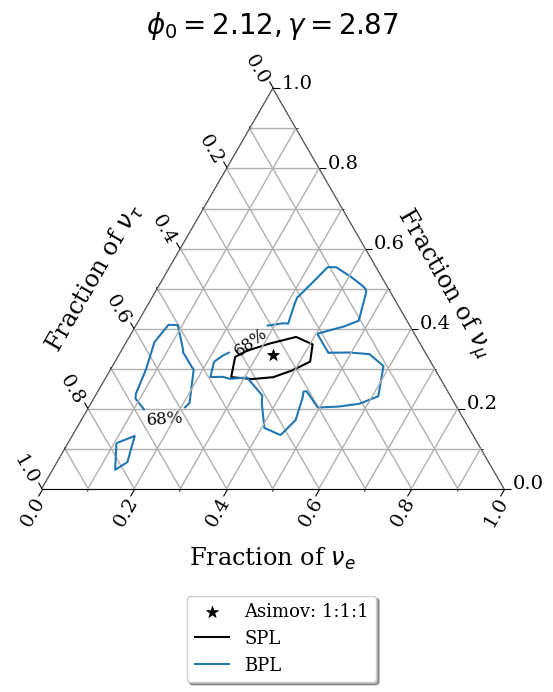

In [13]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_hese_SPL",
"globalfit_double_hese_BPL",
]
labels = [
    "SPL",
    "BPL",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_SPL", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


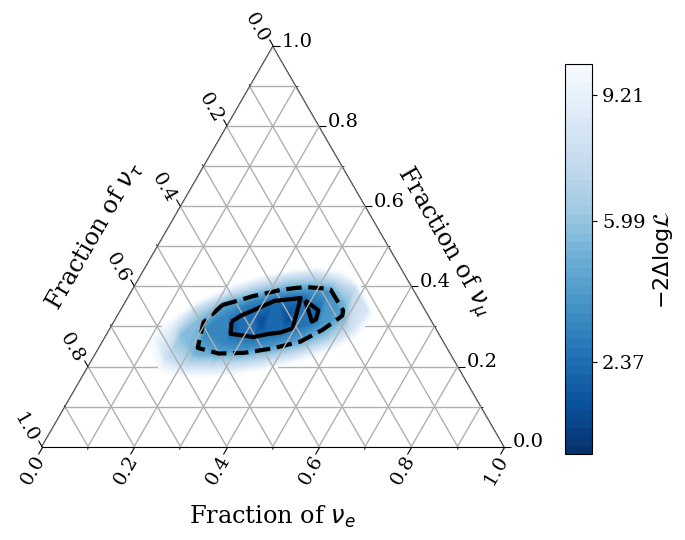

In [7]:
likelihood_contour(data = data,
                  name = "globalfit_double_hese_SPL",
                  levels = ["68%","90%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_hese_lik.png")